In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Abalone
abalone = fetch_openml(name='abalone', version=1, as_frame=True)

df = abalone.frame.copy()
df.head()


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Class_number_of_rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
# Rings
X = df.drop(columns=['Class_number_of_rings'])
y = df['Class_number_of_rings']

# Sex - dummies
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

X = X.to_numpy()
y = y.to_numpy()

In [10]:

r2_values = []
r2_values_batch = []

# Parâmetros
i = 0
N = 50  # tamanho da batelada
P = 50  # passo entre bateladas


Xp = X[i:i+N, :]
yp = y[i:i+N]


vars = np.var(Xp, axis=0)
print(vars)


[0.01316161 0.008983840000000002 0.00125309 0.1687864544
 0.02872193160000001 0.0097650809 0.013196272399999997 0.14759999999999995
 0.23039999999999997]


In [6]:
# Modelo inicial
clf = DecisionTreeRegressor()

# treino e teste
X_train, X_test, y_train, y_test = train_test_split(Xp, yp, test_size=0.3, random_state=42)


clf.fit(X_train, y_train)
y_predict = clf.predict(X_test)
r2 = r2_score(y_test, y_predict)


r2_values.append(r2)
r2_values_batch.append(r2)


In [7]:
# Loop de processamento
while Xp.shape[0] == N:
    i += P
    Xp = X[i:i+N, :]
    yp = y[i:i+N]


    if Xp.shape[0] == 0:
        break


    vars = np.var(Xp, axis=0)


    y_predict = clf.predict(Xp)
    r2 = r2_score(yp, y_predict)
    r2_values_batch.append(r2)

    # Re-treinamento
    Xp = X[:i+N, :]
    yp = y[:i+N]

    clf = DecisionTreeRegressor()
    X_train, X_test, y_train, y_test = train_test_split(Xp, yp, test_size=0.3, random_state=42)
    clf.fit(X_train, y_train)

    y_predict = clf.predict(X_test)
    r2 = r2_score(y_test, y_predict)
    r2_values.append(r2)


In [8]:
print("R² acumulado:", r2_values)
print("R² por batelada:", r2_values_batch)


R² acumulado: [-1.1508728179551126, 0.3077195467422096]
R² por batelada: [-1.1508728179551126, -0.5574518893102967]


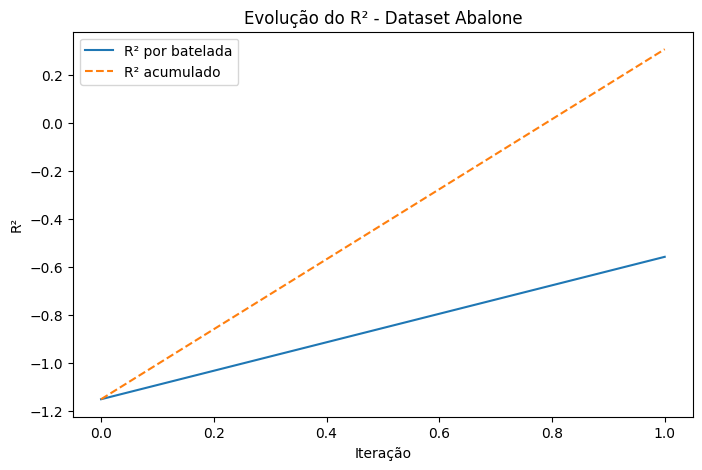

In [9]:
# Visualização da evolução do desempenho
plt.figure(figsize=(8,5))
plt.plot(r2_values_batch, label='R² por batelada')
plt.plot(r2_values, label='R² acumulado', linestyle='--')
plt.xlabel('Iteração')
plt.ylabel('R²')
plt.title('Evolução do R² - Dataset Abalone')
plt.legend()
plt.show()
